# VQA Múa Lân — Train & Eval (A1, A2, A3)

Huấn luyện và đánh giá **3 cấu hình decoder** trên cùng pipeline:

| Run | Decoder       | Norm      | FFN        | Ghi chú |
|-----|---------------|-----------|------------|---------|
| **A1** | LSTM        | —         | —          | Baseline rời (RNN cổ điển) |
| **A2** | Transformer | LayerNorm | VanillaFFN | Transformer cổ điển |
| **A3** | Transformer | RMSNorm   | SwiGLU     | Modern stack (LLaMA / Gemma / Qwen) |

Encoder cố định: SigLIP2-B/16 (layer −2, frozen) + PhoBERT-v2 (mean 4 last layers, frozen) + Cross-Attention Fusion.
Loss: `CrossEntropy(ignore_index=PAD, label_smoothing=0.1)`.

> **Precompute pretrained**: SigLIP2 + PhoBERT-v2 sẽ được tải về 1 lần và lưu vào working space (`/kaggle/working/pretrained/`). Các lần chạy sau load từ disk, không cần kết nối HuggingFace.

## 0. Kaggle Setup

In [1]:
!git clone https://github.com/KhanhNamYeh/qa-domain

Cloning into 'qa-domain'...
remote: Enumerating objects: 117, done.
remote: Counting objects: 100% (117/117), done.
remote: Compressing objects: 100% (84/84), done.
remote: Total 117 (delta 54), reused 93 (delta 32), pack-reused 0 (from 0)
Receiving objects: 100% (117/117), 224.02 KiB | 3.07 MiB/s, done.
Resolving deltas: 100% (54/54), done.


In [2]:
!pwd

/kaggle/working


In [3]:
!ls

qa-domain


In [4]:
!pip install pyvi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 56.8 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 47.9 MB/s eta 0:00:00


## 1. Setup

In [5]:
import os, sys, time, json, random
import numpy as np
import torch
import matplotlib.pyplot as plt

# PROJECT_ROOT = os.path.abspath('.')
PROJECT_ROOT = os.path.abspath('/kaggle/working/qa-domain')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from src.config import ModelConfig, TrainConfig
from src.build  import (build_tokenizer_and_processor, resolve_special_ids,
                        build_loaders, build_model)
from src.training import Trainer, Evaluator
from src.metrics  import ExactMatch, BLEUScore, METEORScore

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('project_root =', PROJECT_ROOT)
print('device       =', DEVICE)

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

project_root = /kaggle/working/qa-domain
device       = cuda


## 1.5. Precompute pretrained weights (chạy 1 lần)

Tải SigLIP2 + PhoBERT-v2 từ HuggingFace, gọi `save_pretrained()` để lưu thẳng vào working space. Các lần chạy sau (kể cả khi không có internet) sẽ load từ thư mục local — bỏ qua hoàn toàn HuggingFace.

In [6]:
from transformers import AutoModel, AutoTokenizer, AutoImageProcessor

# Working space cho weight + cache pretrained.
WORKSPACE_DIR = '/kaggle/working' if os.path.isdir('/kaggle/working') else PROJECT_ROOT
PRETRAINED_DIR = os.path.join(WORKSPACE_DIR, 'pretrained')
SIGLIP_LOCAL  = os.path.join(PRETRAINED_DIR, 'siglip2-base-patch16-224')
PHOBERT_LOCAL = os.path.join(PRETRAINED_DIR, 'phobert-base-v2')
os.makedirs(PRETRAINED_DIR, exist_ok=True)

SIGLIP_HF  = 'google/siglip2-base-patch16-224'
PHOBERT_HF = 'vinai/phobert-base-v2'

def _has_local(path):
    """Coi là cached khi có config.json trong thư mục."""
    return os.path.isdir(path) and os.path.exists(os.path.join(path, 'config.json'))

# --- SigLIP2 ---
if _has_local(SIGLIP_LOCAL):
    print(f'[SigLIP2] cached at {SIGLIP_LOCAL}')
else:
    print(f'[SigLIP2] downloading from HF -> {SIGLIP_LOCAL}')
    _m = AutoModel.from_pretrained(SIGLIP_HF)
    _m.save_pretrained(SIGLIP_LOCAL)
    AutoImageProcessor.from_pretrained(SIGLIP_HF).save_pretrained(SIGLIP_LOCAL)
    del _m

# --- PhoBERT-v2 ---
if _has_local(PHOBERT_LOCAL):
    print(f'[PhoBERT-v2] cached at {PHOBERT_LOCAL}')
else:
    print(f'[PhoBERT-v2] downloading from HF -> {PHOBERT_LOCAL}')
    _m = AutoModel.from_pretrained(PHOBERT_HF)
    _m.save_pretrained(PHOBERT_LOCAL)
    AutoTokenizer.from_pretrained(PHOBERT_HF, use_fast=False).save_pretrained(PHOBERT_LOCAL)
    del _m

print('SIGLIP_LOCAL  =', SIGLIP_LOCAL)
print('PHOBERT_LOCAL =', PHOBERT_LOCAL)

[SigLIP2] downloading from HF -> /kaggle/working/pretrained/siglip2-base-patch16-224


config.json:   0%|          | 0.00/253 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.50G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

model.safetensors:   0%|          | 0.00/540M [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

SIGLIP_LOCAL  = /kaggle/working/pretrained/siglip2-base-patch16-224
PHOBERT_LOCAL = /kaggle/working/pretrained/phobert-base-v2


## 1.6. Precompute encoded features (chạy 1 lần)

Encode toàn bộ train/val/test qua SigLIP2 + PhoBERT-v2 (đã frozen) ngay bây giờ, lưu thành `.npy` (fp16) trong `<WORKSPACE>/cache/{train,val,test}/`.

**Lợi ích chính:**
- Khi train, model chỉ chạy `Linear(768→512) + Fusion + Decoder` — không gọi SigLIP/PhoBERT mỗi batch nữa.
- Một epoch giảm ~10× thời gian (đa số chi phí trước đây nằm ở 2 backbone).
- Restart kernel → load lại trong vài giây, không cần GPU cho phần encode.

In [7]:
from transformers import AutoTokenizer, AutoImageProcessor
from src.data import precompute_split, is_cached

CACHE_ROOT = os.path.join(WORKSPACE_DIR, 'cache')
os.makedirs(CACHE_ROOT, exist_ok=True)

# Đường dẫn JSON + ảnh — cần thiết để encode
TRAIN_JSON = os.path.join(PROJECT_ROOT, 'qa_data', 'train.json')
VAL_JSON   = os.path.join(PROJECT_ROOT, 'qa_data', 'val.json')
TEST_JSON  = os.path.join(PROJECT_ROOT, 'qa_data', 'test.json')
IMAGE_ROOT = os.path.join('/kaggle/input/datasets/namkhn/qa-domain', 'images') \
             if os.path.isdir('/kaggle/input/datasets/namkhn/qa-domain/images') \
             else os.path.join(PROJECT_ROOT, 'images')

MAX_Q_LEN, MAX_A_LEN = 32, 64

# Tokenizer + image processor đọc từ thư mục local đã save_pretrained ở cell 1.5
tokenizer = AutoTokenizer.from_pretrained(PHOBERT_LOCAL, use_fast=False)
image_processor = AutoImageProcessor.from_pretrained(SIGLIP_LOCAL)

for split, jp in [('train', TRAIN_JSON), ('val', VAL_JSON), ('test', TEST_JSON)]:
    out = os.path.join(CACHE_ROOT, split)
    if is_cached(out):
        print(f'[{split}] cached at {out}')
        continue
    print(f'[{split}] precomputing -> {out}')
    precompute_split(
        json_path=jp,
        tokenizer=tokenizer,
        image_processor=image_processor,
        siglip_path=SIGLIP_LOCAL,
        phobert_path=PHOBERT_LOCAL,
        image_root=IMAGE_ROOT,
        out_dir=out,
        max_question_len=MAX_Q_LEN,
        max_answer_len=MAX_A_LEN,
        batch_size=32,
        device=DEVICE,
        save_dtype='float16',
    )
print('CACHE_ROOT =', CACHE_ROOT)

[train] precomputing -> /kaggle/working/cache/train


Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

  [9879/9879]
  saved -> /kaggle/working/cache/train
[val] precomputing -> /kaggle/working/cache/val


Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

  [1235/1235]
  saved -> /kaggle/working/cache/val
[test] precomputing -> /kaggle/working/cache/test


Loading weights:   0%|          | 0/408 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

  [1235/1235]
  saved -> /kaggle/working/cache/test
CACHE_ROOT = /kaggle/working/cache


## 2. Cached DataLoaders (đọc từ npy precomputed)

In [8]:
from src.build import build_cached_loaders

# Probe ModelConfig chỉ để có vocab_size / pad_id / bos_id / eos_id từ tokenizer.
_probe_cfg = ModelConfig(
    image_encoder_name=SIGLIP_LOCAL,
    text_encoder_name=PHOBERT_LOCAL,
    max_answer_len=MAX_A_LEN,
)
_probe_cfg = resolve_special_ids(tokenizer, _probe_cfg)

BATCH_SIZE = 64           # có thể tăng vì không còn chạy 2 backbone trong train loop
EPOCHS     = 50
LR         = 5e-4

CKPT_DIR = os.path.join(WORKSPACE_DIR, 'checkpoints')
HIST_DIR = os.path.join(WORKSPACE_DIR, 'logs')
os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(HIST_DIR, exist_ok=True)

shared_train_cfg = TrainConfig(
    train_json=TRAIN_JSON, val_json=VAL_JSON, test_json=TEST_JSON,
    image_root=IMAGE_ROOT,
    batch_size=BATCH_SIZE, epochs=EPOCHS, lr=LR, num_workers=2,
    ckpt_dir=CKPT_DIR, log_dir=HIST_DIR,
    max_question_len=MAX_Q_LEN, max_answer_len=MAX_A_LEN,
    eval_every=1, save_every=EPOCHS,
)
train_loader, val_loader, test_loader = build_cached_loaders(CACHE_ROOT, shared_train_cfg)
print(f'train={len(train_loader.dataset)}  val={len(val_loader.dataset)}  test={len(test_loader.dataset)}')
print(f'sample img_feat shape:', train_loader.dataset[0]['img_feat'].shape)
print(f'sample txt_feat shape:', train_loader.dataset[0]['txt_feat'].shape)

train=9879  val=1235  test=1235
sample img_feat shape: torch.Size([196, 768])
sample txt_feat shape: torch.Size([32, 768])


## 3. Trainer-with-history

Bọc lại `Trainer` để lưu `train_loss` và mọi metric val theo từng epoch — phục vụ vẽ biểu đồ line.

In [9]:
class TrainerWithHistory(Trainer):
    def __init__(self, *a, **kw):
        super().__init__(*a, **kw)
        self.history = {'train_loss': [], 'val': {}}
    def fit(self):
        cfg = self.train_cfg
        for epoch in range(cfg.epochs):
            t0 = time.time()
            tl = self.train_one_epoch(epoch)
            self.history['train_loss'].append(tl)
            log = f'epoch={epoch+1}/{cfg.epochs} train_loss={tl:.4f} time={time.time()-t0:.1f}s'
            if self.evaluator is not None and self.val_loader is not None:
                res = self.evaluator.evaluate(self.model, self.val_loader)
                for k, v in res.items():
                    self.history['val'].setdefault(k, []).append(v)
                log += '  ' + ' '.join(f'val_{k}={v:.4f}' for k, v in res.items())
            self._log(log)
        self._save_ckpt('final')
        return self.history

In [10]:
from src.build import build_cached_model

def run_config(tag, decoder_type, norm_type='layernorm', ffn_type='vanilla'):
    """Train cached VQA model. `norm_type`/`ffn_type` chỉ ảnh hưởng khi
    decoder_type='transformer'."""
    print(f'\n========== {tag} ==========')
    mcfg = ModelConfig(
        image_encoder_name=SIGLIP_LOCAL,
        text_encoder_name=PHOBERT_LOCAL,
        decoder_type=decoder_type, norm_type=norm_type, ffn_type=ffn_type,
        max_answer_len=MAX_A_LEN,
    )
    mcfg = resolve_special_ids(tokenizer, mcfg)
    tcfg = TrainConfig(
        train_json=TRAIN_JSON, val_json=VAL_JSON, test_json=TEST_JSON,
        image_root=IMAGE_ROOT,
        batch_size=BATCH_SIZE, epochs=EPOCHS, lr=LR, num_workers=2,
        ckpt_dir=CKPT_DIR, log_dir=HIST_DIR,
        max_question_len=MAX_Q_LEN, max_answer_len=MAX_A_LEN,
        eval_every=1, save_every=EPOCHS, run_name=tag,
    )
    model = build_cached_model(mcfg)
    metrics = [ExactMatch(), BLEUScore(), METEORScore()]
    evaluator = Evaluator(
        tokenizer=tokenizer, metrics=metrics,
        bos_id=mcfg.bos_id, eos_id=mcfg.eos_id, pad_id=mcfg.pad_id,
        max_len=mcfg.max_answer_len, beam_size=1,
    )
    trainer = TrainerWithHistory(
        model=model, train_loader=train_loader, val_loader=val_loader,
        train_cfg=tcfg, model_cfg=mcfg, evaluator=evaluator,
    )
    history = trainer.fit()
    return history, trainer, evaluator, model

## 4. Train A1 — LSTM

In [11]:
hist_A1, trainer_A1, evaluator_A1, model_A1 = run_config(
    'A1_lstm', decoder_type='lstm')


========== A1_lstm ==========
[2026-05-04 16:54:33] epoch=1/50 train_loss=5.4586 time=95.1s  val_exact_match=0.0000 val_bleu=0.0012 val_meteor=0.1424
[2026-05-04 16:56:10] epoch=2/50 train_loss=4.5650 time=94.7s  val_exact_match=0.0000 val_bleu=0.0101 val_meteor=0.2761
[2026-05-04 16:57:47] epoch=3/50 train_loss=4.0507 time=94.2s  val_exact_match=0.0000 val_bleu=0.1416 val_meteor=0.4095
[2026-05-04 16:59:24] epoch=4/50 train_loss=3.4123 time=94.4s  val_exact_match=0.0664 val_bleu=0.1685 val_meteor=0.3956
[2026-05-04 17:01:01] epoch=5/50 train_loss=2.8163 time=94.5s  val_exact_match=0.0356 val_bleu=0.3985 val_meteor=0.5555
[2026-05-04 17:02:38] epoch=6/50 train_loss=2.4932 time=94.6s  val_exact_match=0.1385 val_bleu=0.4405 val_meteor=0.6024
[2026-05-04 17:04:15] epoch=7/50 train_loss=2.3149 time=94.6s  val_exact_match=0.1603 val_bleu=0.4802 val_meteor=0.6389
[2026-05-04 17:05:52] epoch=8/50 train_loss=2.2082 time=94.4s  val_exact_match=0.1563 val_bleu=0.4872 val_meteor=0.6436
[2026-05-

## 5. Train A2 — Transformer + LayerNorm + VanillaFFN

In [12]:
hist_A2, trainer_A2, evaluator_A2, model_A2 = run_config(
    'A2_transformer_vanilla', decoder_type='transformer', norm_type='layernorm', ffn_type='vanilla')


========== A2_transformer_vanilla ==========
[2026-05-04 18:15:10] epoch=1/50 train_loss=2.8602 time=70.5s  val_exact_match=0.2316 val_bleu=0.5241 val_meteor=0.6812
[2026-05-04 18:16:29] epoch=2/50 train_loss=1.9979 time=70.6s  val_exact_match=0.2559 val_bleu=0.5730 val_meteor=0.7423
[2026-05-04 18:17:47] epoch=3/50 train_loss=1.8936 time=70.5s  val_exact_match=0.3174 val_bleu=0.6189 val_meteor=0.7554
[2026-05-04 18:19:06] epoch=4/50 train_loss=1.8327 time=70.2s  val_exact_match=0.3368 val_bleu=0.6237 val_meteor=0.7619
[2026-05-04 18:20:24] epoch=5/50 train_loss=1.7939 time=70.5s  val_exact_match=0.3555 val_bleu=0.6444 val_meteor=0.7814
[2026-05-04 18:21:43] epoch=6/50 train_loss=1.7665 time=70.3s  val_exact_match=0.3457 val_bleu=0.6415 val_meteor=0.7778
[2026-05-04 18:23:01] epoch=7/50 train_loss=1.7459 time=70.3s  val_exact_match=0.3595 val_bleu=0.6434 val_meteor=0.7779
[2026-05-04 18:24:20] epoch=8/50 train_loss=1.7253 time=70.6s  val_exact_match=0.3474 val_bleu=0.6211 val_meteor=0

## 6. Train A3 — Transformer + RMSNorm + SwiGLU

In [13]:
hist_A3, trainer_A3, evaluator_A3, model_A3 = run_config(
    'A3_transformer_modern', decoder_type='transformer', norm_type='rmsnorm', ffn_type='swiglu')


========== A3_transformer_modern ==========
[2026-05-04 19:20:57] epoch=1/50 train_loss=2.8239 time=75.4s  val_exact_match=0.2243 val_bleu=0.5489 val_meteor=0.7074
[2026-05-04 19:22:20] epoch=2/50 train_loss=1.9841 time=75.2s  val_exact_match=0.2518 val_bleu=0.5650 val_meteor=0.7198
[2026-05-04 19:23:45] epoch=3/50 train_loss=1.8795 time=75.3s  val_exact_match=0.3004 val_bleu=0.6069 val_meteor=0.7463
[2026-05-04 19:25:09] epoch=4/50 train_loss=1.8238 time=75.1s  val_exact_match=0.3498 val_bleu=0.6358 val_meteor=0.7713
[2026-05-04 19:26:34] epoch=5/50 train_loss=1.7883 time=75.1s  val_exact_match=0.3417 val_bleu=0.6095 val_meteor=0.7512
[2026-05-04 19:27:58] epoch=6/50 train_loss=1.7557 time=74.9s  val_exact_match=0.3457 val_bleu=0.6416 val_meteor=0.7778
[2026-05-04 19:29:22] epoch=7/50 train_loss=1.7372 time=75.3s  val_exact_match=0.3457 val_bleu=0.6335 val_meteor=0.7706
[2026-05-04 19:30:46] epoch=8/50 train_loss=1.7199 time=75.0s  val_exact_match=0.3312 val_bleu=0.6241 val_meteor=0.

## 7. So sánh — biểu đồ line

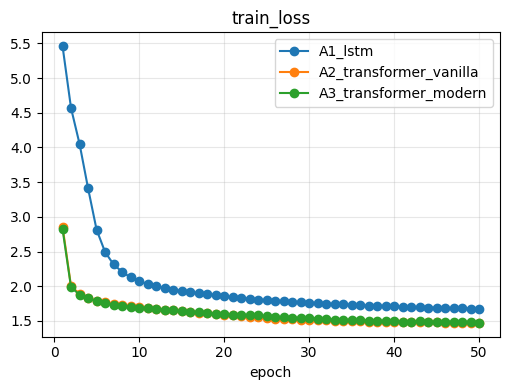

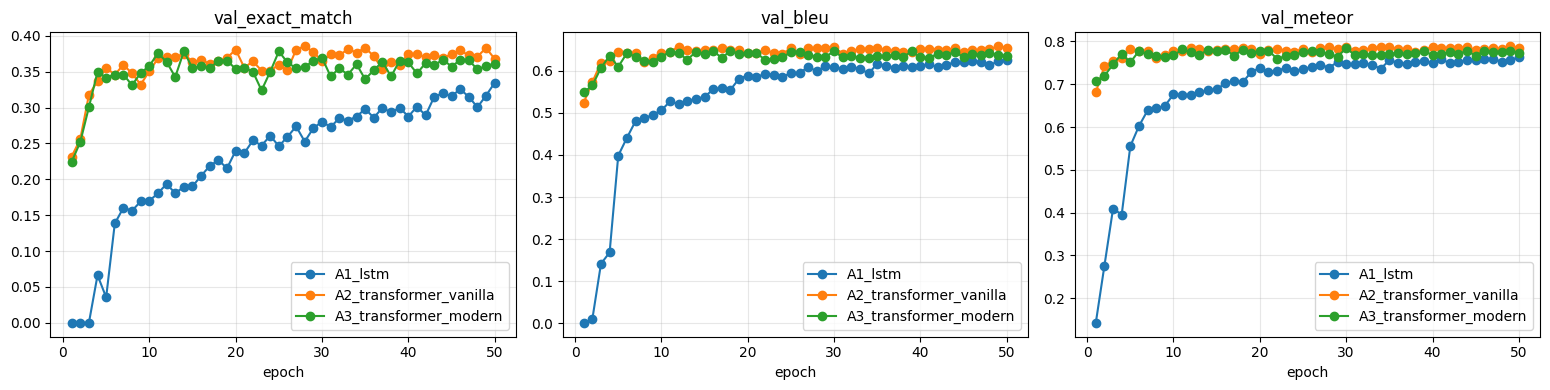

In [14]:
def plot_compare(histories, keys, title_prefix=''):
    n = len(keys)
    fig, axes = plt.subplots(1, n, figsize=(5.2*n, 4))
    if n == 1: axes = [axes]
    for ax, key in zip(axes, keys):
        for tag, h in histories.items():
            ys = h['train_loss'] if key == 'train_loss' else h['val'].get(key, [])
            xs = list(range(1, len(ys)+1))
            ax.plot(xs, ys, marker='o', label=tag)
        ax.set_title(f'{title_prefix}{key}')
        ax.set_xlabel('epoch'); ax.grid(True, alpha=0.3); ax.legend()
    plt.tight_layout(); plt.show()

histories = {
    'A1_lstm':                hist_A1,
    'A2_transformer_vanilla': hist_A2,
    'A3_transformer_modern':  hist_A3,
}
plot_compare(histories, ['train_loss'])
plot_compare(histories, ['exact_match', 'bleu', 'meteor'], title_prefix='val_')

## 8. Đánh giá cuối trên test split (Exact Match, BLEU, METEOR)

In [15]:
test_results = {}
for tag, model in [('A1_lstm', model_A1),
                   ('A2_transformer_vanilla', model_A2),
                   ('A3_transformer_modern',  model_A3)]:
    metrics = [ExactMatch(), BLEUScore(), METEORScore()]
    ev = Evaluator(
        tokenizer=tokenizer, metrics=metrics,
        bos_id=_probe_cfg.bos_id, eos_id=_probe_cfg.eos_id, pad_id=_probe_cfg.pad_id,
        max_len=_probe_cfg.max_answer_len, beam_size=1,
    )
    test_results[tag] = ev.evaluate(model, test_loader)
    print(tag, test_results[tag])

A1_lstm {'exact_match': 0.3174089068825911, 'bleu': 0.6023177386687919, 'meteor': 0.7487039579591438}
A2_transformer_vanilla {'exact_match': 0.35384615384615387, 'bleu': 0.6400666872434542, 'meteor': 0.7796992974518471}
A3_transformer_modern {'exact_match': 0.35060728744939273, 'bleu': 0.6196618988970312, 'meteor': 0.7644498219616227}


## 8.5. Attention visualization (1 sample test)

Chọn 1 sample test, chạy model qua `AttnCapture` (monkey-patch `MultiheadAttention.forward` để bắt `attn_weights`), vẽ 3 loại attention:

1. **Fusion** (text Q × visual KV) — 3 block. Mỗi block reshape về 14×14 patch grid của ảnh.
2. **Decoder self-attn** (answer × answer, causal) — 3 block. Ma trận tam giác dưới.
3. **Decoder cross-attn** (answer × memory) — 3 block. Hàng = token answer, cột = token text-fused.

Visualization chỉ hiển thị cho **A2/A3** (Transformer); LSTM (A1) không có MultiheadAttention nên sẽ skip với cảnh báo.

In [16]:
import torch.nn as nn

class AttnCapture:
    """Patch every nn.MultiheadAttention forward to also return its weights,
    keyed by module-name. Restores originals on exit."""
    def __init__(self, model):
        self.model = model
        self.weights = {}
        self._patches = []

    def __enter__(self):
        store = self.weights
        for name, mod in self.model.named_modules():
            if isinstance(mod, nn.MultiheadAttention):
                orig = mod.forward
                def make_wrap(n, om):
                    def wrapped(*args, **kwargs):
                        kwargs['need_weights'] = True
                        kwargs['average_attn_weights'] = True
                        out, w = om(*args, **kwargs)
                        if w is not None:
                            store[n] = w.detach().cpu().float()
                        return out, w
                    return wrapped
                mod.forward = make_wrap(name, orig)
                self._patches.append((mod, orig))
        return self

    def __exit__(self, *a):
        for mod, orig in self._patches:
            mod.forward = orig

# ---- pick 1 sample from test ----
SAMPLE_IDX = 1
sample = test_loader.dataset[SAMPLE_IDX]
img_feat = sample['img_feat'].unsqueeze(0).to(DEVICE)
txt_feat = sample['txt_feat'].unsqueeze(0).to(DEVICE)
txt_mask = sample['txt_mask'].unsqueeze(0).to(DEVICE)
ans_in   = sample['answer_in'].unsqueeze(0).to(DEVICE)
question = sample['raw_question']
target   = sample['raw_answer']

print(f'Q: {question}')
print(f'A: {target}')

# Pick model — Transformer (A2) by default; fall back to A3 if available.
viz_model = (model_A2 if 'model_A2' in dir() else model_A3).eval()

with torch.no_grad():
    with AttnCapture(viz_model) as cap:
        logits = viz_model(img_feat=img_feat, txt_feat=txt_feat,
                           txt_mask=txt_mask, answer_in=ans_in)

pred_ids = logits.argmax(-1)[0].cpu().tolist()
pred_text = tokenizer.decode(
    [t for t in pred_ids if t not in (_probe_cfg.pad_id, _probe_cfg.bos_id, _probe_cfg.eos_id)],
    skip_special_tokens=True,
).replace('_', ' ').strip()
print(f'Predicted: {pred_text}')

print('\nCaptured attentions:')
for n, w in cap.weights.items():
    print(f'  {n:50s} {tuple(w.shape)}')

Q: Con lân có màu sắc chủ đạo nào?
A: Con lân có màu vàng và đen chủ đạo.
Predicted: Con lân có màu vàng và đen xen đạo. đenđenđenđenđenđenđenđenđenđenđenđenđenđenđenđenđenđenđenđenđenđenđenđenđenđenđenđenđenđenđenđenđenđenđenđenđenđenđenđenđenđenđen@@

Captured attentions:
  fusion.blocks.0.attn                               (1, 32, 196)
  fusion.blocks.1.attn                               (1, 32, 196)
  fusion.blocks.2.attn                               (1, 32, 196)
  decoder.blocks.0.self_attn.attn                    (1, 64, 64)
  decoder.blocks.0.cross_attn.attn                   (1, 64, 32)
  decoder.blocks.1.self_attn.attn                    (1, 64, 64)
  decoder.blocks.1.cross_attn.attn                   (1, 64, 32)
  decoder.blocks.2.self_attn.attn                    (1, 64, 64)
  decoder.blocks.2.cross_attn.attn                   (1, 64, 32)


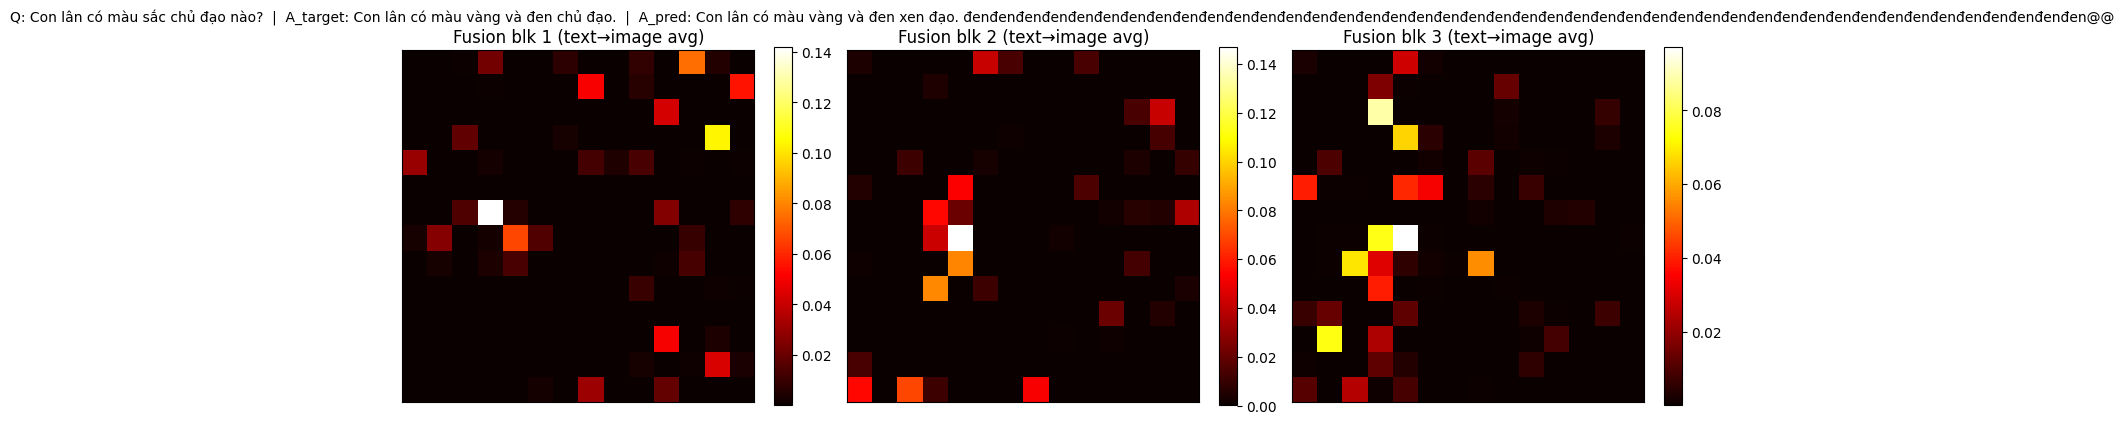

saved -> /kaggle/working/logs/attn_viz/sample1_fusion.png


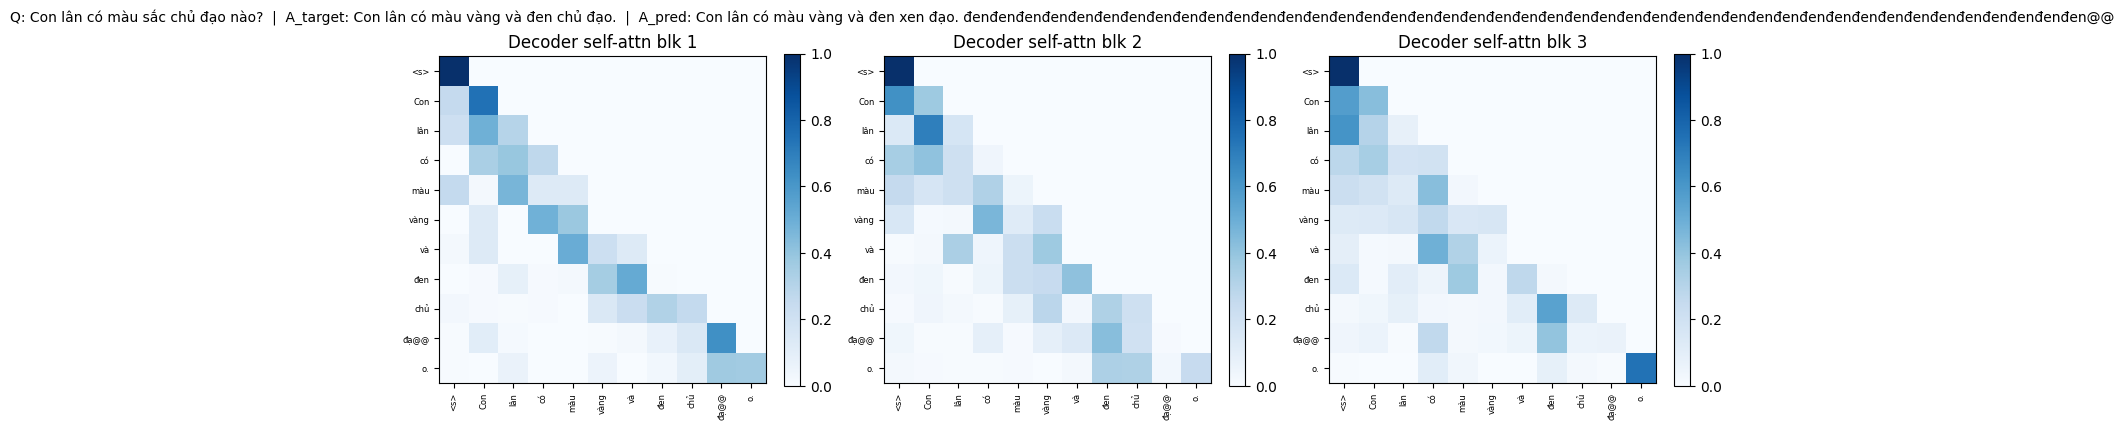

saved -> /kaggle/working/logs/attn_viz/sample1_decoder_self.png


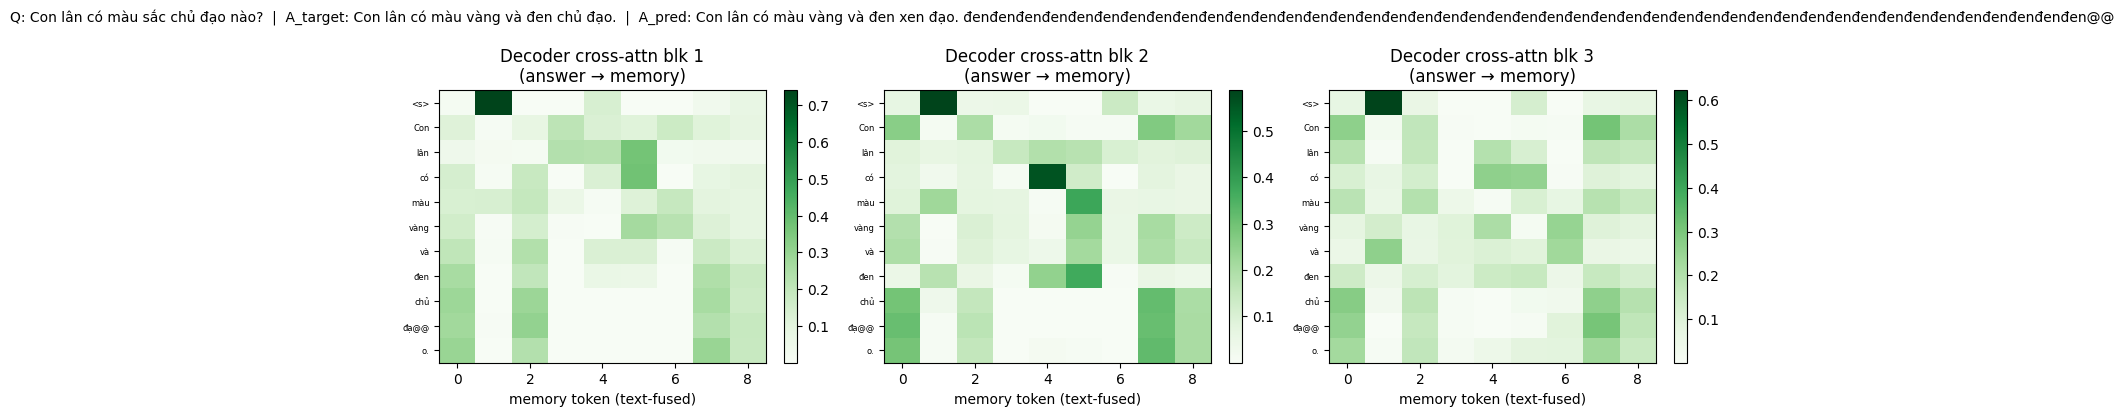

saved -> /kaggle/working/logs/attn_viz/sample1_decoder_cross.png


In [17]:
import math
import numpy as np

# --- helpers --------------------------------------------------------------
T_q_valid = int(txt_mask[0].sum().item())
T_a_valid = int((ans_in[0] != _probe_cfg.pad_id).sum().item())

# Decode answer-side tokens for axis labels
ans_tokens = []
for tid in ans_in[0].cpu().tolist()[:T_a_valid]:
    s = tokenizer.decode([tid], skip_special_tokens=False)
    ans_tokens.append(s.strip() or f'#{tid}')

VIZ_DIR = os.path.join(HIST_DIR, 'attn_viz')
os.makedirs(VIZ_DIR, exist_ok=True)
fig_suptitle = f'Q: {question}  |  A_target: {target}  |  A_pred: {pred_text}'

# --- 1. Fusion (text → image patches, 14×14) ----------------------------
fusion_keys = sorted([k for k in cap.weights if k.startswith('fusion.blocks.')])
if fusion_keys:
    n = len(fusion_keys)
    fig, axes = plt.subplots(1, n, figsize=(4.5 * n, 4.2))
    if n == 1: axes = [axes]
    for i, k in enumerate(fusion_keys):
        w = cap.weights[k][0]                   # (T_q, T_v)
        T_v = w.shape[1]
        side = int(round(math.sqrt(T_v)))       # 14
        # Trung bình attention từ các text token hợp lệ
        avg = w[:T_q_valid].mean(dim=0).reshape(side, side).numpy()
        im = axes[i].imshow(avg, cmap='hot')
        axes[i].set_title(f'Fusion blk {i+1} (text→image avg)')
        axes[i].set_xticks([]); axes[i].set_yticks([])
        plt.colorbar(im, ax=axes[i], fraction=0.046)
    fig.suptitle(fig_suptitle, fontsize=10)
    plt.tight_layout()
    fig_path = os.path.join(VIZ_DIR, f'sample{SAMPLE_IDX}_fusion.png')
    plt.savefig(fig_path, dpi=120, bbox_inches='tight')
    plt.show()
    print('saved ->', fig_path)

# --- 2. Decoder self-attn (answer × answer, causal) ----------------------
self_keys = sorted([k for k in cap.weights if k.endswith('.self_attn.attn')])
if self_keys:
    n = len(self_keys)
    fig, axes = plt.subplots(1, n, figsize=(4.5 * n, 4.2))
    if n == 1: axes = [axes]
    for i, k in enumerate(self_keys):
        w = cap.weights[k][0][:T_a_valid, :T_a_valid].numpy()
        im = axes[i].imshow(w, cmap='Blues')
        axes[i].set_title(f'Decoder self-attn blk {i+1}')
        axes[i].set_xticks(range(T_a_valid))
        axes[i].set_yticks(range(T_a_valid))
        axes[i].set_xticklabels(ans_tokens, rotation=90, fontsize=6)
        axes[i].set_yticklabels(ans_tokens, fontsize=6)
        plt.colorbar(im, ax=axes[i], fraction=0.046)
    fig.suptitle(fig_suptitle, fontsize=10)
    plt.tight_layout()
    fig_path = os.path.join(VIZ_DIR, f'sample{SAMPLE_IDX}_decoder_self.png')
    plt.savefig(fig_path, dpi=120, bbox_inches='tight')
    plt.show()
    print('saved ->', fig_path)

# --- 3. Decoder cross-attn (answer → memory) -----------------------------
cross_keys = sorted([k for k in cap.weights if k.endswith('.cross_attn.attn')])
if cross_keys:
    n = len(cross_keys)
    fig, axes = plt.subplots(1, n, figsize=(4.5 * n, 4.2))
    if n == 1: axes = [axes]
    for i, k in enumerate(cross_keys):
        w = cap.weights[k][0][:T_a_valid, :T_q_valid].numpy()
        im = axes[i].imshow(w, cmap='Greens', aspect='auto')
        axes[i].set_title(f'Decoder cross-attn blk {i+1}\n(answer → memory)')
        axes[i].set_xlabel('memory token (text-fused)')
        axes[i].set_yticks(range(T_a_valid))
        axes[i].set_yticklabels(ans_tokens, fontsize=6)
        plt.colorbar(im, ax=axes[i], fraction=0.046)
    fig.suptitle(fig_suptitle, fontsize=10)
    plt.tight_layout()
    fig_path = os.path.join(VIZ_DIR, f'sample{SAMPLE_IDX}_decoder_cross.png')
    plt.savefig(fig_path, dpi=120, bbox_inches='tight')
    plt.show()
    print('saved ->', fig_path)

if not (fusion_keys or self_keys or cross_keys):
    print('No MultiheadAttention captured — model có thể là LSTM (A1). '
          'Đặt viz_model = model_A2 hoặc model_A3 để chạy lại.')

## 9. Lưu lại history + test results

In [18]:
os.makedirs(HIST_DIR, exist_ok=True)
summary_path = os.path.join(HIST_DIR, 'train_eval_A_history.json')
with open(summary_path, 'w', encoding='utf-8') as f:
    json.dump({'history': histories, 'test': test_results}, f, ensure_ascii=False, indent=2)
print('saved ->', summary_path)

saved -> /kaggle/working/logs/train_eval_A_history.json
